# Data inputs: what the analysis uses, how current it is, and how it was checked

**Review notebook** for the data layer: connectors in `srmp/ingest/`, the exposure aggregation in `srmp/exposure/`, and the reference files in `data/reference/` (ADR-0027, ADR-0028, ADR-0035). It follows the human-review standard in `AGENTS.md`.

*How to use:* run all cells. Read-only. Refreshing sources calls external APIs (Google Trends, Yahoo Finance, GDELT, Wikimedia) and is deliberately **not** offered from this notebook; run `python -m srmp.pipeline --with-pulls` instead.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

MANIFESTS = {
    "Google Trends: Lenovo queries": "data/raw/trends/pull_manifest.json",
    "Google Trends: donor brand panels": "data/staged/trends_joint_donors/pull_manifest.json",
    "Google Trends: co-brand placebo panels": "data/staged/trends_cobrand_placebos/pull_manifest.json",
    "Share prices, rates, indices": "data/raw/market/pull_manifest.json",
    "GDELT news volume and tone": "data/raw/gdelt/pull_manifest.json",
    "Wikipedia pageviews": "data/raw/wikipedia/pull_manifest.json",
    "Blinkfire exposure (client)": "data/staged/blinkfire/pull_manifest.json",
    "Media values (client)": "data/staged/media_values/pull_manifest.json",
    "FIFA World Cup calendar": "data/staged/fifa_calendar/pull_manifest.json",
}
REFERENCE = ["data/reference/lenovo_quarterly_financials.csv", "data/reference/lenovo_annual_financials.csv",
             "data/reference/lenovo_financial_results_events.csv", "data/reference/lenovo_product_campaign_events.csv",
             "data/reference/counterfactual_donor_registry.csv", "data/reference/property_taxonomy.csv"]
stamp_sources(list(MANIFESTS.values()) + REFERENCE)
manifests = {name: json.loads(Path(path).read_text(encoding="utf-8")) for name, path in MANIFESTS.items()}

REVIEW_SOURCES={"data/raw/trends/pull_manifest.json": "05bf27078c1eb42bbe701d7c4c3f258cb7ba708d7c7a08f6d2cb5dc498fee593", "data/staged/trends_joint_donors/pull_manifest.json": "f36fd001cc243a0091a7b3a33c5278ecafbc08fe71a1758bbef2fbb6b35a4d26", "data/staged/trends_cobrand_placebos/pull_manifest.json": "19a3b36387199f4eb64dbd036703b9433297af9b8f2c4116d23dc4cccb268a84", "data/raw/market/pull_manifest.json": "92ffbbd169ed3e9aaac0bdd5c2f154f181f66c722394cac284ed625ef7d8e914", "data/raw/gdelt/pull_manifest.json": "93ba32bbb6874bbea24c6464075c1db7e2b911cb7141dca0f0f287cce62a9e81", "data/raw/wikipedia/pull_manifest.json": "6b820ab59f0c80b0301897c6f30073a309a0fe07c151d8d31a27dc53e2cfc007", "data/staged/blinkfire/pull_manifest.json": "9dafbcfdd38fff87f5e7a0a7817cf6b95e09d532ae7b33bcac99250b73c35131", "data/staged/media_values/pull_manifest.json": "1addc3c12bc9897b4de7dd097c8a97bcb530767e1b774f5f251a8d74e8672fc9", "data/staged/fifa_calendar/pull_manifest.json": "1016a86a62c888ba5a89eed28ee9e00d89

## 1. Question and purpose

**Question.** Which data does the analysis rely on, how current is each source, which are observed versus constructed, and did each pull pass its checks?

**Why it matters.** Every estimate inherits the coverage, vintage and quality of its inputs. A reader must be able to see, for example, that brand data run to late September 2026 while exposure data stop on 20 July 2026, before interpreting any World Cup result.

**Objective supported.** Data readiness and provenance for all downstream analyses.

## 2. Evidence and inputs

| Source | What it measures | Provider | Label | Used for |
|---|---|---|---|---|
| Google Trends, "Lenovo" and related queries | Relative worldwide search interest (0–100 per request) | Google | **observed** (sampled, rounded) | Search-salience cross-check index; product-demand indicator |
| Google Trends donor panels | Search interest for rival brands, on a common "Lenovo" anchor scale | Google | **observed** → **constructed** (rescaled) | Brand Index (share of search) and synthetic controls |
| Google Trends co-brand panels | "<brand> FIFA / World Cup" searches on a "Lenovo FIFA" anchor | Google | **observed** → **constructed** | Co-brand placebo test |
| GWI Core crosstab | Quarterly engagement and consideration of Lenovo in the GWI online population | Client export (GWI) | **observed** survey estimates; non-canonical anchor | Brand Index (quarterly measurements) |
| Share prices, HSI, Nasdaq-100, USD/HKD, US 10y yield, ACWI | Daily closes | Yahoo Finance chart API | **observed** | Stock response, brand value (10y yield and ACWI unused since the DCF was retired) |
| GDELT | Daily Lenovo news volume and tone | GDELT DOC API | **observed** | Index comparison (not the headline index) |
| Wikipedia | Daily pageviews (Lenovo and rival brand articles) | Wikimedia | **observed** | Brand Index validity screen (failed; sensitivity only) |
| Blinkfire | Daily impressions/views by sponsored property (digital/social only) | Client | **observed** | Exposure weights |
| Media values | Vendor media-equivalency value by competition and market | Client (vendor) | **estimated** by vendor; used only as relative weight | Sensitivity (ADR-0028) |
| FIFA calendar | 104 official World Cup 2026 matches | FIFA API | **observed** | Tournament dates |
| Lenovo financials and events | Results, balance sheet, launch events | Lenovo releases, stockanalysis.com | **observed** | Valuation, event controls |
| Donor registry | Which brands may serve as comparisons | Project screen | **assumed** (evidence-bounded) | Synthetic controls |

## 3. Method and conventions

- **Raw data are immutable.** Each connector writes the raw response once (`data/raw/`), then stages a typed table (`data/staged/`). Google Trends raw files go into a folder per pull end date so later pulls never overwrite earlier ones; `.gitattributes` stores `data/raw` byte-for-byte so manifest hashes stay valid.
- **Weeks.** Google Trends weeks start on Sunday; the Brand Index and experiments use weeks starting on Monday (Trends week + 1 day).
- **Common-anchor rescaling.** Google Trends rescales every request to 0–100. Each donor panel includes the same anchor query; panel $k$ draw $d$ is multiplied by $f_{kd} = \sum_t A^{ref}_t / \sum_t A^{kd}_t$ over weeks where both anchor series are positive, putting all brands on the reference panel's scale. *In words:* the shared anchor tells us how to convert each panel's 0–100 scale into a common one.
- **Overlap-ratio rescaling** (Lenovo queries): ten overlapping time windows are rescaled to a full-horizon reference by the ratio of their summed interest, and averaged.
- **Provisional weeks.** The last two weeks of any Trends pull are revised by Google and are excluded from estimation.
- **Blinkfire merge rule.** A later export replaces an earlier one on overlapping dates; each export must reconcile exactly to its own TOTAL row.

## 4. Calculation path

| Source | Connector | Configuration | Staged / curated output |
|---|---|---|---|
| Lenovo Trends | `srmp/ingest/trends.py` | `config/queries_trends.yaml` | `data/curated/trends/trends_weekly_averaged.parquet` |
| Donor and co-brand panels | `srmp/ingest/trends_joint.py` | `config/joint_trends_donors.yaml`, `config/cobrand_placebo_trends.yaml` | `data/curated/trends/*.parquet` |
| Market | `srmp/ingest/market.py` | `config/market.yaml` | `data/staged/market/` |
| GDELT, Wikipedia | `srmp/ingest/gdelt.py`, `srmp/ingest/wikipedia.py` | `config/gdelt.yaml`, `config/wikipedia.yaml` | `data/staged/gdelt/`, `data/staged/wikipedia/` |
| Blinkfire | `srmp/ingest/blinkfire.py` → `srmp/exposure/aggregate.py` | `data/reference/property_taxonomy.csv` | `data/staged/blinkfire/` |
| Media values | `srmp/ingest/media_values.py` | — | `data/staged/media_values/` |
| FIFA calendar | `srmp/ingest/fifa_calendar.py` | `config/fifa_calendar.yaml` | `data/staged/fifa_calendar/` |
| All of the above, in order | `python -m srmp.pipeline --with-pulls` | — | — |

## 5. Results

### 5.1 Inventory and freshness

In [2]:
def coverage(name, m):
    if "date_min" in m: return m["date_min"], m["date_max"]
    if "horizon" in m: return m["horizon"]["start"], m["horizon"]["end"]
    if "first_match_utc" in m: return m["first_match_utc"][:10], m["final_match_utc"][:10]
    return None, None
rows = []
for name, m in manifests.items():
    start, end = coverage(name, m)
    rows.append({"Source": name, "Pulled / staged (UTC)": str(m.get("generated_at_utc", ""))[:16].replace("T", " "),
                 "Coverage from": start, "Coverage to": end, "Status": m.get("status", "ok"),
                 "Rows": m.get("row_count", m.get("normalized_rows", m.get("matches")))})
inventory = pd.DataFrame(rows)
# Trends manifests record the request window; report the last complete week actually returned.
for label, path in [("Google Trends: Lenovo queries", "data/curated/trends/trends_weekly_averaged.parquet"),
                    ("Google Trends: donor brand panels", "data/curated/trends/jointly_scaled_donor_trends.parquet"),
                    ("Google Trends: co-brand placebo panels", "data/curated/trends/cobrand_placebo_trends.parquet")]:
    weeks = pd.read_parquet(path, columns=["week"])["week"]
    inventory.loc[inventory["Source"].eq(label), ["Coverage from", "Coverage to"]] = [str(weeks.min())[:10], f"week of {str(weeks.max())[:10]}"]
display(inventory.style.format({"Rows": "{:,.0f}"}, na_rep="—").hide(axis="index"))

Source,Pulled / staged (UTC),Coverage from,Coverage to,Status,Rows
Google Trends: Lenovo queries,2026-10-05 09:58,2021-12-26,week of 2026-09-27,incomplete_draw_set,—
Google Trends: donor brand panels,2026-10-06 12:58,2021-12-26,week of 2026-09-27,usable_incomplete_joint_scale_panel,—
Google Trends: co-brand placebo panels,2026-10-06 13:04,2021-12-26,week of 2026-09-27,complete_joint_scale_panel,—
"Share prices, rates, indices",2026-10-05 14:09,2022-01-01,2026-10-05,ok,"7,148"
GDELT news volume and tone,2026-10-05 09:53,2022-01-01,2026-10-05,doc_api_complete,"1,707"
Wikipedia pageviews,2026-10-05 08:56,2022-01-01,2026-10-04,ok,"15,642"
Blinkfire exposure (client),2026-10-09 08:00,2024-01-01,2026-09-30,complete_client_scope,"13,052"
Media values (client),2026-10-05 08:58,2025-05-01,2026-04-01,staged_comparison_only,"66,610"
FIFA World Cup calendar,2026-10-08 08:19,2026-06-11,2026-07-19,ok,104


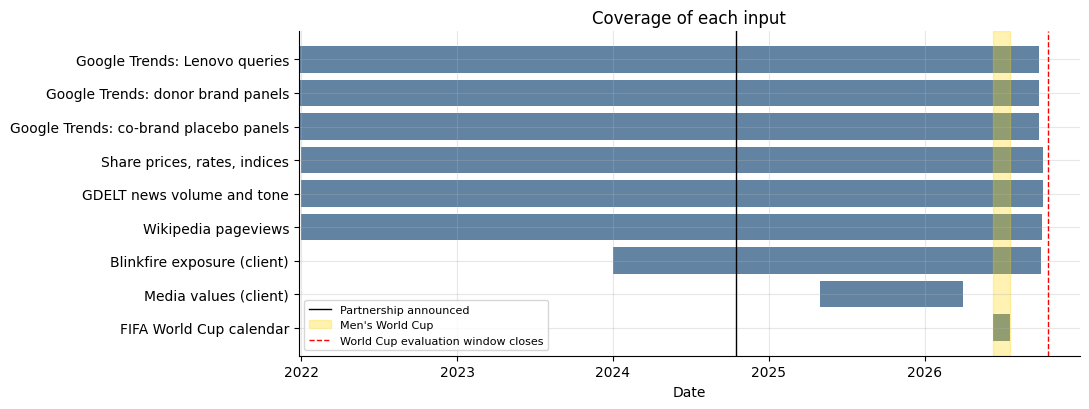

**Figure 1.** Brand and market data reach early October 2026; Blinkfire exposure stops at 2026-09-30; media values cover only 2025-05-01 to 2026-04-01, i.e. not the 2026 World Cup.

In [3]:
bars = inventory.dropna(subset=["Coverage from", "Coverage to"]).copy()
bars["start"] = pd.to_datetime(bars["Coverage from"]); bars["end"] = pd.to_datetime(bars["Coverage to"].str.replace("week of ", ""))
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, row in enumerate(bars.itertuples()):
    ax.barh(i, (row.end - row.start).days, left=row.start, color="#1f4e79", alpha=0.7)
ax.set_yticks(range(len(bars)), bars["Source"]); ax.invert_yaxis()
ax.axvline(pd.Timestamp("2024-10-15"), color="black", lw=1, label="Partnership announced")
ax.axvspan(pd.Timestamp("2026-06-11"), pd.Timestamp("2026-07-19"), color="gold", alpha=0.3, label="Men's World Cup")
ax.axvline(pd.Timestamp("2026-10-18"), color="red", ls="--", lw=1, label="World Cup evaluation window closes")
ax.set_title("Coverage of each input"); ax.set_xlabel("Date"); ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()
md(f"**Figure 1.** Brand and market data reach early October 2026; Blinkfire exposure stops at {manifests['Blinkfire exposure (client)']['date_max']}; "
   f"media values cover only {manifests['Media values (client)']['date_min']} to {manifests['Media values (client)']['date_max']}, i.e. not the 2026 World Cup.")

### 5.2 Quality and reconciliation checks

In [4]:
t = manifests["Google Trends: Lenovo queries"]
j = manifests["Google Trends: donor brand panels"]
c = manifests["Google Trends: co-brand placebo panels"]
b = manifests["Blinkfire exposure (client)"]
g = manifests["GDELT news volume and tone"]
checks = pd.DataFrame([
    {"Check": "Lenovo Trends draws returned", "Result": f"{t['fetched_draws_ok']} of {t['fetched_draws_ok'] + t['fetched_draws_failed']}",
     "Note": "Failures: " + ", ".join(sorted({x.split('__')[0] for x in t['missing_exports']})) if t['missing_exports'] else "none"},
    {"Check": "Donor panel draws (10 per panel)", "Result": f"min {min(j['successful_draws_by_panel'].values())}, {j['panels']} panels",
     "Note": j["status"]},
    {"Check": "Co-brand panel draws (10 per panel)", "Result": f"min {min(c['successful_draws_by_panel'].values())}, {c['panels']} panels", "Note": c["status"]},
    *[{"Check": f"Blinkfire export reconciles to its TOTAL row: {Path(e['path']).name}", "Result": e["total_row_validation"],
       "Note": f"{e['dated_rows']} days, {e['date_min']} to {e['date_max']}; overlapping days replaced: {len(e['overlapping_dates_replaced'])}"} for e in b["exports"]],
    {"Check": "GDELT calendar days missing", "Result": f"{g['missing_calendar_day_count']} of {g['calendar_day_count']}", "Note": g["status"]},
])
display(checks.style.hide(axis="index"))
failed_queries = sorted({x.split("__")[0] for x in t["missing_exports"]})
md(f"**Table 2.** Every Blinkfire export reconciles exactly to its TOTAL row (the connector refuses to stage one that does not). "
   f"Lenovo Trends queries with failed draws: {', '.join(failed_queries) or 'none'}; the headline 'brand_lenovo' query "
   f"{'is affected' if 'brand_lenovo' in failed_queries else 'is complete'}. GDELT misses {g['missing_calendar_day_count']} days and is not used by the headline index.")

Check,Result,Note
Lenovo Trends draws returned,164 of 170,Failures: cobrand_fcwc
Donor panel draws (10 per panel),"min 9, 10 panels",usable_incomplete_joint_scale_panel
Co-brand panel draws (10 per panel),"min 10, 6 panels",complete_joint_scale_panel
Blinkfire export reconciles to its TOTAL row: lenovo_sponsorship_exposure_daily_export.csv,passed,"619 days, 2024-10-01 to 2026-06-11; overlapping days replaced: 0"
Blinkfire export reconciles to its TOTAL row: impressions_views_by_2024.xlsx,passed,"274 days, 2024-01-01 to 2024-09-30; overlapping days replaced: 0"
Blinkfire export reconciles to its TOTAL row: impressions_views_by_wc.xlsx,passed,"40 days, 2026-06-11 to 2026-07-20; overlapping days replaced: 1"
Blinkfire export reconciles to its TOTAL row: impressions_views_by_wc_sept.xlsx,passed,"72 days, 2026-07-21 to 2026-09-30; overlapping days replaced: 0"
GDELT calendar days missing,32 of 1739,doc_api_complete


**Table 2.** Every Blinkfire export reconciles exactly to its TOTAL row (the connector refuses to stage one that does not). Lenovo Trends queries with failed draws: cobrand_fcwc; the headline 'brand_lenovo' query is complete. GDELT misses 32 days and is not used by the headline index.

In [5]:
registry = pd.read_csv("data/reference/counterfactual_donor_registry.csv")
display(registry.groupby("inclusion_policy")["query_id"].apply(lambda s: ", ".join(q.replace("donor_", "") for q in s))
        .rename("Brands").to_frame().rename_axis("Donor registry policy"))
md("**Table 3.** Donor screening outcome. 'excluded': FIFA or World Cup activity found (Samsung, LG gram); 'data_quality_excluded': mostly empty or "
   "constant before the announcement; 'sensitivity': used only in robustness checks. Screening is evidence-bounded: no sponsorship found is not proof of none.")

,Brands
Donor registry policy,
base,"dell, asus, acer, hp, microsoft_surface, razer..."
candidate_base,"intel, amd, kingston, sony, xiaomi, tp_link, s..."
data_quality_excluded,"gigabyte, toshiba, fujitsu, vaio, framework, a..."
excluded,"lg_gram, samsung"
sensitivity,"huawei, msi"


**Table 3.** Donor screening outcome. 'excluded': FIFA or World Cup activity found (Samsung, LG gram); 'data_quality_excluded': mostly empty or constant before the announcement; 'sensitivity': used only in robustness checks. Screening is evidence-bounded: no sponsorship found is not proof of none.

## 6. Interpretation

- The brand-side data (search, market, news) are current to early October 2026, with the last two Trends weeks provisional.
- Exposure data are current only to 20 July 2026. Any analysis needing exposure after the World Cup final is waiting on the client.
- Media values cannot inform the World Cup period; they only support a 2025–26 sensitivity.
- The donor pool has grown from 11 to 26 screened brands, which improves the precision of synthetic-control tests.

## 7. Limitations and non-claims

- **Google Trends** comes from an unofficial endpoint, is sampled and rounded, and is relative (not volumes). Draw-to-draw variation is reduced, not removed.
- **Blinkfire** covers digital and social exposure only, not broadcast audiences.
- **Media values** are a vendor's monetary estimate; the currency and method are undocumented. They are never used as money (ARCHITECTURE P1).
- **Balance-sheet figures** come from a secondary aggregator rather than the annual report.
- **Pinned vintage:** `config/joint_trends_donors.yaml` is pinned to the 5 October 2026 pull so new donors share its scale; it must be reset to `null` at the next refresh.

## Next steps

After 18 October 2026: run `python -m srmp.pipeline --with-pulls --tests` (with the donor pin reset), then re-run all review notebooks with `python -m srmp.review`.